## Linear Regression Using Pytorch

* Linear regression in PyTorch is implemented by defining a simple linear model, calculating the loss

* The model learns the relationship between input and output by minimizing the error during training through backpropagation

## Step 1 : Data(Preparing and Loading)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch

print(torch.__version__)

2.10.0+cpu


In [2]:
# create parameters for regression

weight = 0.7

bais = 0.3

start = 0

end = 1

step = 0.02

X = torch.arange(start , end , step).unsqueeze(dim=1)

y = weight * X + bais

X[:10] , y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

Spliting an data

In [3]:
# create train/test split

train_split = int(0.8 * len(X))

X_train , y_train = X[:train_split] , y[:train_split]

X_test , y_test = X[train_split:] , y[train_split:]

print(f"Length of X_train : {len(X_train)}")

print(f"Length of y_train : {len(y_train)}")

print(f"Length of X_test : {len(X_test)}")

print(f"Length of y_test : {len(y_test)}")

Length of X_train : 40
Length of y_train : 40
Length of X_test : 10
Length of y_test : 10


In [4]:
def plot_predictions(train_data = X_train , train_labels = y_train,
                     test_data = X_test , test_labels = y_test,
                     predictions = None):
  """plots training data , test data and compare predictions """

  plt.figure(figsize=(10,7))

  plt.scatter(train_data , train_labels , c="b" , s=4 , label="training data")

  plt.scatter(test_data , test_labels , c="g" , s=4 , label="testing data")

  if predictions is not None :

    plt.scatter(test_data , predictions , c="r" , s=4 , label="predictions")

  plt.legend(prop={"size" : 14})

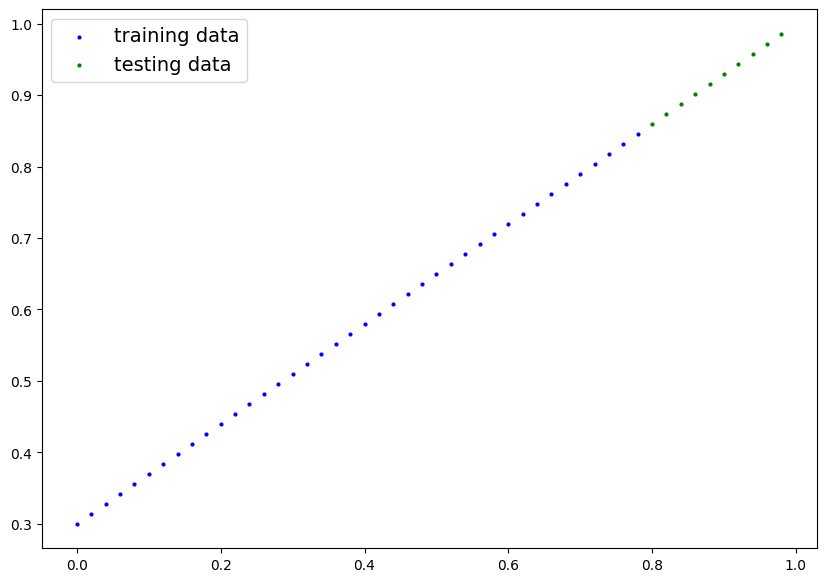

In [5]:
plot_predictions()

## Step 2 : Build Model

In [8]:
import torch.nn as nn

# Create Linear Regression MOdel class


class LinearRegressionModel(nn.Module):
  def __init__(self):
    super().__init__()
    self.weights = nn.Parameter(torch.randn(1,
                                            dtype=torch.float,
                                            requires_grad=True
                                            ))
    self.bais = nn.Parameter(torch.randn(1,
                                         dtype=torch.float,
                                         requires_grad=True))

  def forward(self , x : torch.Tensor) -> torch.Tensor:
    return self.weights * x + self.bais

checking contents of pytorch model

In [9]:
torch.manual_seed(42)

# creating instance of model

model = LinearRegressionModel()

list(model.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [10]:
model.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bais', tensor([0.1288]))])

making predicitons using inference_mode

In [14]:
with torch.inference_mode():

  y_preds = model(X_test)

y_preds

tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])

In [15]:
print(f"Number of testing samples: {len(X_test)}")

print(f"Number of predictions made: {len(y_preds)}")

Number of testing samples: 10
Number of predictions made: 10


Plotting Predictions

* Predictions are made randomly

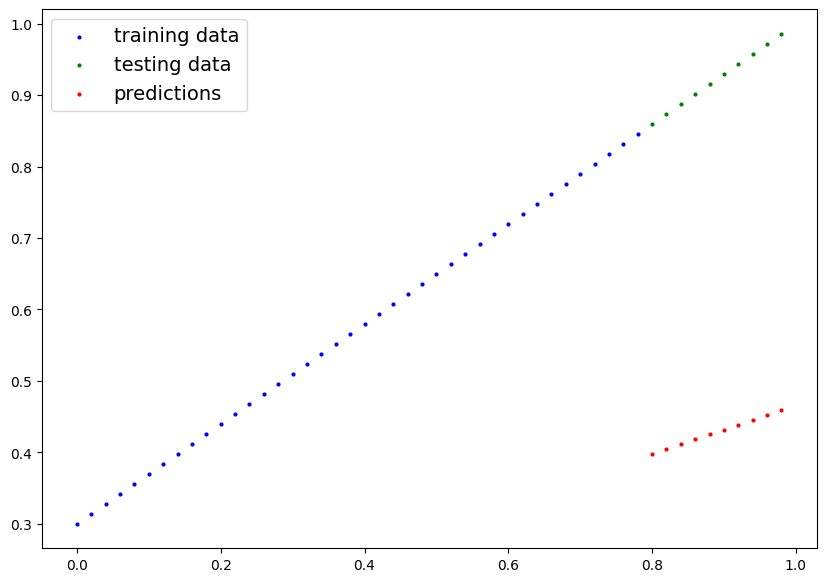

In [16]:
plot_predictions(predictions=y_preds)

In [17]:
y_test - y_preds

tensor([[0.4618],
        [0.4691],
        [0.4764],
        [0.4836],
        [0.4909],
        [0.4982],
        [0.5054],
        [0.5127],
        [0.5200],
        [0.5272]])

predictions look pretty bad...

# Step 3 : Train model

Creating a loss function and optimizer in PyTorch

In [18]:
# create loss function

loss_fn =  nn.L1Loss()

"""L1Loss : calculates the Mean Absolute Error (MAE) between each element in the input and target tensors """

# create optimizer

optimizer = torch.optim.SGD(params=model.parameters(),
                          lr=0.01)

PyTorch training loop

In [20]:
torch.manual_seed = 42

epochs = 100

train_loss_values = []

test_loss_values = []

epoch_count = []

for epoch in range(epochs):

  # training
  model.train()

  # 1.Forward pass on train data
  y_pred = model(X_train)

  # 2.Calculate the loss
  loss = loss_fn(y_pred , y_train)

  # 3. zero grad optimizer
  optimizer.zero_grad()

  # 4. Loss Backward(Back propagation)
  loss.backward()

  # Progress optimizer
  optimizer.step()

  # Testing Loop
  model.eval()

  with torch.inference_mode():

    test_pred = model(X_test)

    test_loss = loss_fn(test_pred , y_test.type(torch.float))

    if epoch % 10 == 0 :

      epoch_count.append(epoch)

      train_loss_values.append(loss.detach().numpy())

      test_loss_values.append(test_loss.detach().numpy())

      print(f"Epoch : {epoch} | Loss : {loss} | Test Loss : {test_loss}")


Epoch : 0 | Loss : 0.3013603389263153 | Test Loss : 0.4675942063331604
Epoch : 10 | Loss : 0.18615034222602844 | Test Loss : 0.3328842222690582
Epoch : 20 | Loss : 0.08227583020925522 | Test Loss : 0.2069590985774994
Epoch : 30 | Loss : 0.05181945487856865 | Test Loss : 0.14023718237876892
Epoch : 40 | Loss : 0.04503796249628067 | Test Loss : 0.11182951927185059
Epoch : 50 | Loss : 0.04132963344454765 | Test Loss : 0.09809747338294983
Epoch : 60 | Loss : 0.03785243630409241 | Test Loss : 0.08776430785655975
Epoch : 70 | Loss : 0.03441363573074341 | Test Loss : 0.0794917643070221
Epoch : 80 | Loss : 0.030979642644524574 | Test Loss : 0.07190609723329544
Epoch : 90 | Loss : 0.02754882536828518 | Test Loss : 0.06363357603549957


Plot Loss Curves

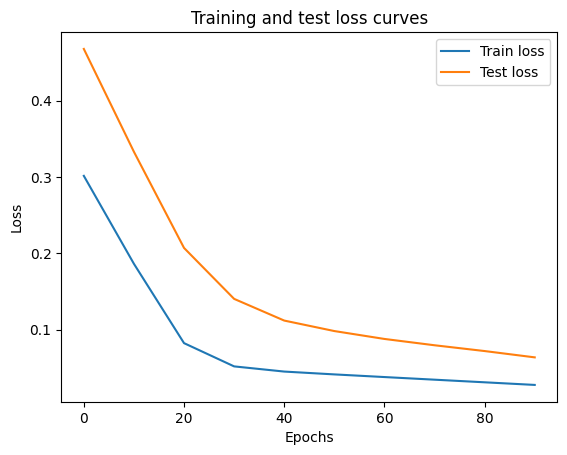

In [21]:
plt.plot(epoch_count, train_loss_values, label="Train loss")

plt.plot(epoch_count, test_loss_values, label="Test loss")

plt.title("Training and test loss curves")

plt.ylabel("Loss")

plt.xlabel("Epochs")

plt.legend();

In [22]:
print(f"The model learned following values for weights and bias : ")

print(model.state_dict())

print("Original values of weights and bias")

print(f"Weights : {weight}")

print(f"Bias : {bais}")

The model learned following values for weights and bias : 
OrderedDict({'weights': tensor([0.5800]), 'bais': tensor([0.3503])})
Original values of weights and bias
Weights : 0.7
Bias : 0.3


# Step 4 : Making Predictions with trained Pytorch Model

In [23]:
# set model in evaluation mode
model.eval()

with torch.inference_mode() :

  y_preds = model(X_test)

y_preds

tensor([[0.8143],
        [0.8259],
        [0.8375],
        [0.8491],
        [0.8607],
        [0.8723],
        [0.8839],
        [0.8955],
        [0.9071],
        [0.9187]])

Plotting predicitons after backpropagation

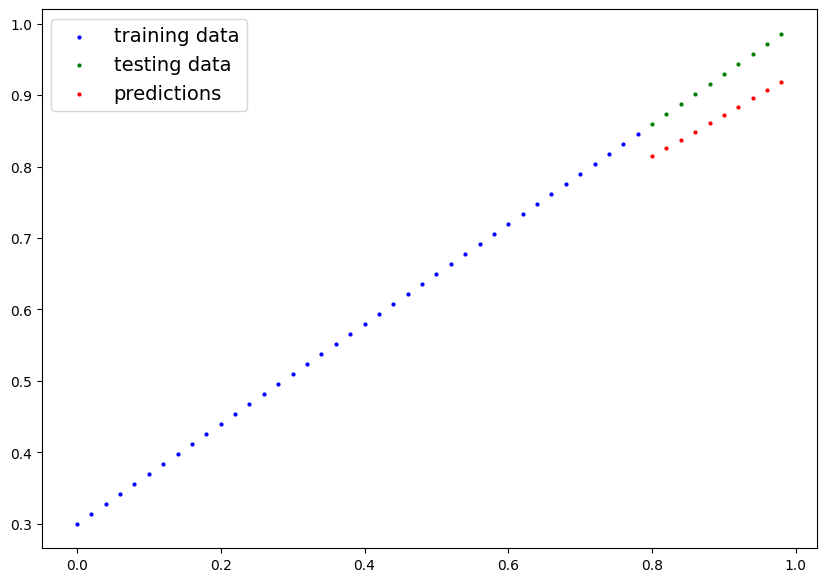

In [24]:
plot_predictions(predictions=y_preds)